<a href="https://colab.research.google.com/github/OmarHanii-bit/Plant-Health-Monitoring/blob/main/Lab01_NYC_Taxi_Section.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 01 — Understanding and Profiling a Large Dataset
**Introduction to Big Data (INF3101)** · Dataset: NYC Yellow Taxi Trips (2024)

**Goal of today:** load a large real dataset with Pandas, explore it (EDA), and **measure** how time and memory grow with data size — to see *why* Big Data needs tools like Hadoop and Spark.

| # | Stage | Question | ~Time |
|---|---|---|---|
| 1 | Data Ingestion & I/O | How long does loading take? | 15 min |
| 2 | Dimensionality & Data Types | What is the shape and meaning of the data? | 10 min |
| 3 | Summary Statistics & Cardinality | What do the values look like? | 15 min |
| 4 | Null Counts & Sparsity | What is missing? | 10 min |
| 5 | Memory Footprint | How much RAM does it need? | 10 min |
| 6 | Scale Barriers | When is one machine not enough? | 20 min |

### The dataset
Each row = **one taxi trip** in New York City, recorded by the taxi meter (NYC Taxi & Limousine Commission).
One month ≈ **3 million trips**, published as **Parquet** files. Source: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

Put the files in a folder named `data` next to this notebook:
```
data/yellow_tripdata_2024-01.parquet   (… up to 2024-06)
data/taxi_zone_lookup.csv
```

## Setup

In [ ]:
# Run ONCE, with internet, if the libraries are missing (then restart the kernel)
# %pip install pandas pyarrow matplotlib psutil

In [ ]:
# One-time download (at home, with internet). Set to True, run, then set back to False.
DOWNLOAD_DATA = False

if DOWNLOAD_DATA:
    import urllib.request, os
    os.makedirs("data", exist_ok=True)
    base = "https://d37ci6vzurychx.cloudfront.net"
    files = [f"trip-data/yellow_tripdata_2024-{m:02d}.parquet" for m in range(1, 7)] + ["misc/taxi_zone_lookup.csv"]
    for f in files:
        target = "data/" + f.split("/")[-1]
        if not os.path.exists(target):
            print("downloading", target)
            req = urllib.request.Request(f"{base}/{f}", headers={"User-Agent": "Mozilla/5.0"})
            with urllib.request.urlopen(req) as r, open(target, "wb") as out:
                out.write(r.read())
    print("Done")

In [ ]:
import time
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import psutil                      # to read the computer's RAM

MB = 1024 ** 2
GB = 1024 ** 3
DATA_DIR = Path("data")

def month_file(m):
    return DATA_DIR / f"yellow_tripdata_2024-{m:02d}.parquet"

months = [m for m in range(1, 13) if month_file(m).exists()]
print("Months available:", months)
print(f"RAM: {psutil.virtual_memory().total / GB:.1f} GB total, "
      f"{psutil.virtual_memory().available / GB:.1f} GB available")

---
## Stage 1 — Data Ingestion & I/O Performance
**Purpose:** data must move from **disk** to **RAM** before we can analyze it. How much does that cost?

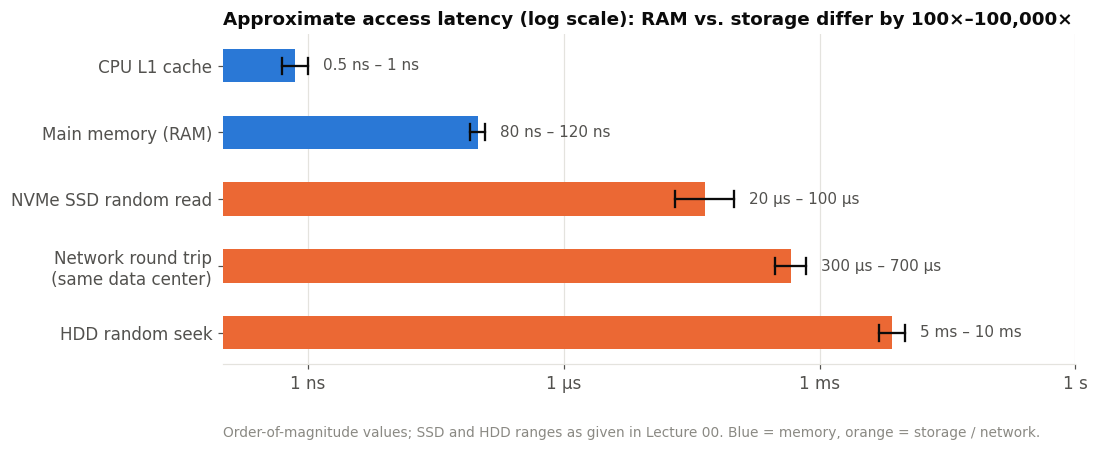

Disk is **hundreds to thousands of times slower** than RAM → loading is often the slowest step.

In [ ]:
file = month_file(1)
print(f"File size on disk: {file.stat().st_size / MB:.1f} MB")

start = time.perf_counter()
df = pd.read_parquet(file)
load_time = time.perf_counter() - start

print(f"Loaded {len(df):,} rows in {load_time:.2f} seconds")

**Parquet is a columnar format:** it can read **only the columns we need**. (A CSV file must be read completely.)

In [ ]:
start = time.perf_counter()
two_cols = pd.read_parquet(file, columns=["fare_amount", "tip_amount"])
print(f"2 columns: {time.perf_counter() - start:.2f} s   vs   all 19 columns: {load_time:.2f} s")

> **Takeaway:** loading time grows with the amount of data read. Reading less (fewer columns, better formats) is the first optimization in Big Data.

---
## Stage 2 — Dataset Dimensionality & Data Types
**Purpose:** know the **size** (rows × columns) and the **type** of every column before analysis.

In [ ]:
print("Shape:", df.shape)
df.head()

In [ ]:
df.dtypes

**Data type ≠ meaning.** Some columns are numbers but are really **codes**:

| Column | Stored as | Real meaning |
|---|---|---|
| `payment_type` | int | 1 = credit card, 2 = cash, 3 = no charge, 4 = dispute |
| `PULocationID` / `DOLocationID` | int | pickup / drop-off zone (1–265) |
| `RatecodeID` | float | 1 = standard, 2 = JFK airport, … |

Taking the *average* of `payment_type` would be meaningless.

In [ ]:
# The file is for January 2024 — are all trips really in January?
print("First pickup:", df["tpep_pickup_datetime"].min())
print("Last pickup :", df["tpep_pickup_datetime"].max())

> **Takeaway:** millions of rows for just **one month**; and even official data contains wrong dates (**Veracity**).

---
## Stage 3 — Summary Statistics & Cardinality
**Purpose:** describe the values and find suspicious ones. **Cardinality** = number of distinct values in a column.

In [ ]:
df[["trip_distance", "fare_amount", "tip_amount", "total_amount", "passenger_count"]].describe()

In [ ]:
# Suspicious values
print("Negative fares      :", (df["fare_amount"] < 0).sum())
print("Zero-distance trips :", (df["trip_distance"] == 0).sum())
print("Zero passengers     :", (df["passenger_count"] == 0).sum())

In [ ]:
# Cardinality: distinct values per column
df.nunique().sort_values()

- **Low cardinality** (e.g. `payment_type`, few values) → categories, good for grouping.
- **High cardinality** (e.g. timestamps, hundreds of thousands of values) → behaves like an ID, expensive to group.

---
## Stage 4 — Null Counts & Sparsity
**Purpose:** find what is **missing** and whether it has a meaning.

In [ ]:
null_pct = (df.isnull().mean() * 100).round(2)
null_pct[null_pct > 0]

**Observe:** several columns have exactly the **same null %** → most likely the same rows are empty in all of them (these trips were recorded differently).

**A zero can also mean "missing":** the TLC records tips **only for credit-card** payments.

In [ ]:
# % of trips with tip = 0, by payment type (1 = credit card, 2 = cash)
(df["tip_amount"] == 0).groupby(df["payment_type"]).mean().mul(100).round(1)

> **Takeaway:** always check what a missing value (or a zero) **means** before analyzing it.

---
## Stage 5 — Memory Footprint Constraints
**Purpose:** measure how much **RAM** the data needs. Parquet on disk is **compressed**; in RAM it is **not**.

In [ ]:
disk_mb = file.stat().st_size / MB
ram_mb = df.memory_usage(deep=True).sum() / MB

print(f"On disk : {disk_mb:,.0f} MB")
print(f"In RAM  : {ram_mb:,.0f} MB   ->  {ram_mb / disk_mb:.1f}x bigger in memory")

In [ ]:
# Which columns use the most memory?
(df.memory_usage(deep=True, index=False) / MB).sort_values().plot.barh(figsize=(8, 5), title="Memory per column (MB)")
plt.show()

In [ ]:
ram_gb = psutil.virtual_memory().total / GB
print(f"One month uses {ram_mb / 1024:.2f} GB  ->  this computer ({ram_gb:.0f} GB RAM) "
      f"could hold at most ~{ram_gb * 1024 / ram_mb:.0f} months of data only")
print("…and operations (sort, merge, copy) need extra memory on top of that.")

> **Takeaway:** data is several times bigger in RAM than on disk, and RAM is **limited**.

---
## Stage 6 — Scale Barriers & Transition to Distributed Systems
**Purpose:** measure how **time** and **memory** grow when the data grows.

**Time complexity (Big-O)** describes how work grows with the input size *n*:

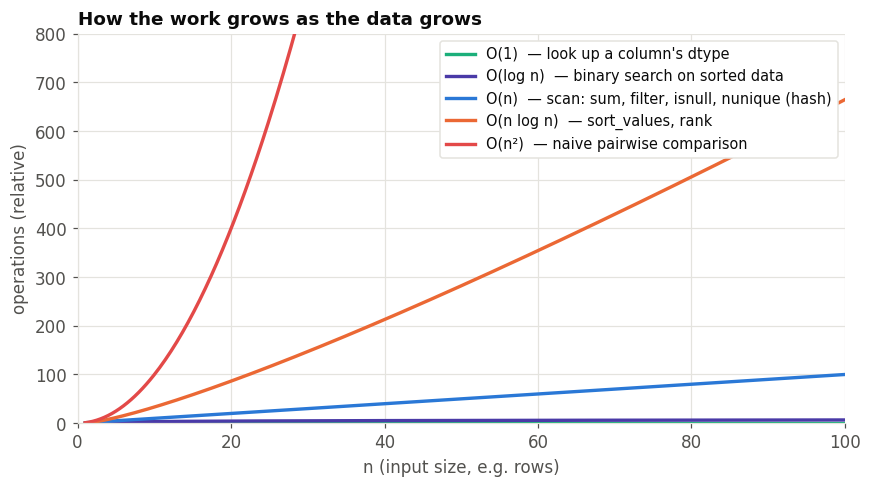

| Operation | Complexity |
|---|---|
| read file, filter, sum, `isnull`, `groupby` | **O(n)** — one pass over the rows |
| `sort_values` | **O(n log n)** |
| memory of a DataFrame | **O(n)** — every row is stored in RAM |

### Experiment: load 1, 2, 3 … months and measure

In [ ]:
results = []
for k in range(1, len(months) + 1):
    # safety check: stop before the computer runs out of memory
    if psutil.virtual_memory().available < ram_mb * MB * k * 3:
        print(f"Stopped at {k} months: not enough RAM!")
        break

    start = time.perf_counter()
    big = pd.concat([pd.read_parquet(month_file(m)) for m in months[:k]], ignore_index=True)
    load_s = time.perf_counter() - start

    start = time.perf_counter()
    big.groupby("PULocationID")["fare_amount"].mean()
    groupby_s = time.perf_counter() - start

    start = time.perf_counter()
    big["total_amount"].sort_values()
    sort_s = time.perf_counter() - start

    results.append({"months": k, "rows_M": len(big) / 1e6,
                    "memory_GB": big.memory_usage(deep=True).sum() / GB,
                    "load_s": load_s, "groupby_s": groupby_s, "sort_s": sort_s})
    print(f"{k} month(s): {len(big):>11,} rows | {results[-1]['memory_GB']:.2f} GB | load {load_s:.1f} s")
    del big

res = pd.DataFrame(results)
res

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
res.plot(x="rows_M", y=["load_s", "groupby_s", "sort_s"], marker="o", ax=ax[0],
         title="Time grows with the rows", xlabel="rows (millions)", ylabel="seconds")
res.plot(x="rows_M", y="memory_GB", marker="o", ax=ax[1], legend=False,
         title="Memory grows with the rows", xlabel="rows (millions)", ylabel="GB")
plt.show()

**Observe:** the lines are close to **straight** → double the data ≈ double the time and memory (**O(n)**).

In [ ]:
gb_per_million = res["memory_GB"].iloc[-1] / res["rows_M"].iloc[-1]
print(f"Memory cost: {gb_per_million:.2f} GB per million rows")
print(f"This computer's RAM ({ram_gb:.0f} GB) is full at ~{ram_gb / gb_per_million:,.0f} million rows")
print(f"1 billion trips would need ~{gb_per_million * 1000:,.0f} GB of RAM")

### So what do we do? Scale up or scale out

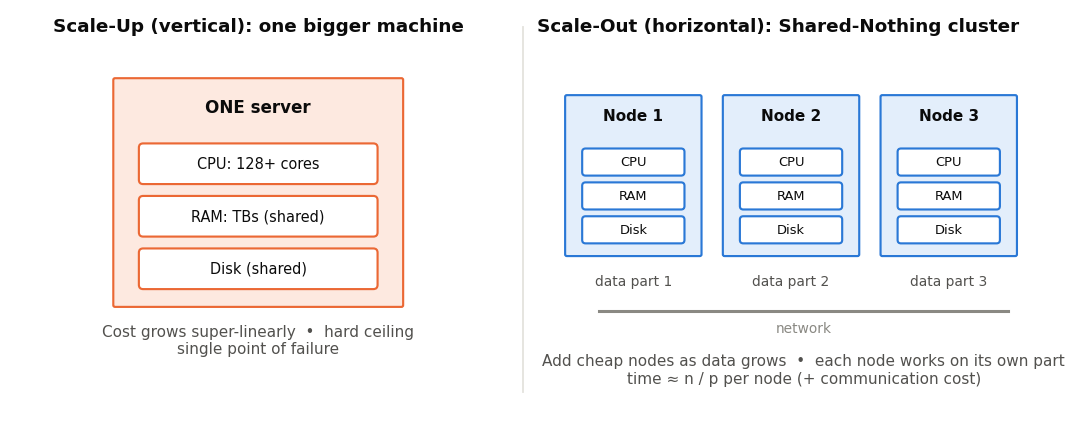

- **Scale-up:** buy a bigger machine → very expensive, has a limit, single point of failure.
- **Scale-out (Shared-Nothing):** many normal machines, each with its own CPU, RAM and disk, each processing **part** of the data.

| Problem we saw today | Solution | Lab |
|---|---|---|
| data does not fit on one machine | **HDFS** — distributed storage | Lab 04 |
| processing must be split across machines | **MapReduce** | Lab 05 |
| Pandas works on one machine only | **Spark** — distributed DataFrames | Lab 07 |

---
## Summary
1. **Ingestion:** loading takes time; Parquet lets us read only the columns we need.
2. **Dimensionality:** millions of rows per month; data types ≠ meaning.
3. **Statistics & Cardinality:** real data has wrong values; cardinality tells categories from IDs.
4. **Sparsity:** missing values (and zeros) have reasons.
5. **Memory:** data is several times bigger in RAM than on disk.
6. **Scale:** time and memory grow **linearly** with the data, but RAM is limited → we need **distributed systems**.

## Deliverable (this week)
Submit a short **profiling report** for one month of data. Start from the table below and answer:
1. What is the size on disk vs. in RAM? Which columns use the most memory?
2. Which columns have **low** and **high** cardinality?
3. Which columns have **nulls**? Why is the tip zero for cash trips?
4. From your Stage 6 results: how many months can your computer handle? Why do we need Spark?

In [ ]:
report = pd.DataFrame({
    "dtype":           df.dtypes.astype(str),
    "distinct values": df.nunique(),
    "null %":          (df.isnull().mean() * 100).round(2),
    "memory (MB)":     (df.memory_usage(deep=True, index=False) / MB).round(1),
})
report.to_csv("lab01_profile_report.csv")
report